# Ajuste fino eficiente: T5 com LoRA

O experimento utiliza FLAN-T5-small, um modelo de geração de texto com codificador e decodificador. A escolha considera a memória disponível, de cerca de 6 GB de RAM, e a ausência de CUDA. LoRA realiza o ajuste eficiente de parâmetros: acrescenta matrizes treináveis ao modelo e mantém os pesos originais congelados. A biblioteca PEFT implementa essa adaptação.

T5 possui codificador e decodificador: recebe a instrução e o contexto e aprende a produzir a resposta-alvo. O perfil local usa float32 sem quantização.

In [ ]:
from pathlib import Path
import json, os, sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*", module="tqdm.auto")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
os.environ["HF_HOME"] = str(ROOT / ".hf-cache")
import torch
from importlib.metadata import version
print({n: version(n) for n in ("torch","transformers","peft")})
print("CUDA:", torch.cuda.is_available())
RUN_TRAINING = False

{'torch': '2.7.1', 'transformers': '4.51.3', 'peft': '0.15.2'}
CUDA: False


## Tokenização, perda e parâmetros treináveis

Tokens são unidades numéricas derivadas do texto. O programa mede os comprimentos antes do treinamento e interrompe a execução se exceder 512 tokens de entrada ou 256 de saída; não descarta conteúdo silenciosamente. O mesmo format_prompt compõe as entradas de treino e inferência.

LoRA acrescenta uma atualização de baixo posto às matrizes de atenção: W' = W + (alpha/r) BA. Os pesos W permanecem congelados. Usamos r=8, alpha=16 e dropout=0,05 nas projeções q e v. A perda de entropia cruzada mede a previsão dos tokens-alvo; uma perda menor não comprova correção clínica.

A taxa de aprendizado é 0,0002. Cada exemplo forma um lote; acumulamos até quatro gradientes por atualização e limitamos sua norma a 1. A semente é 42. São seis épocas, com seleção pela menor perda de validação. Não houve busca de hiperparâmetros orientada pelo teste.

In [2]:
from clinical_assistant.training import run
if RUN_TRAINING:
    run(ROOT, epochs=6)
result_path = ROOT / "docs/results/training.json"
if not result_path.exists():
    raise FileNotFoundError("Execute python -m clinical_assistant.training antes de analisar os resultados.")
result = json.loads(result_path.read_text(encoding="utf-8"))
print("Execução registrada:", result["timestamp_utc"])
print("Modelo:", result["model"], "revisão:", result["model_revision"])
print("Parâmetros treináveis:", result["trainable_parameters"])
print("Proporção:", result["trainable_parameters"] / result["total_parameters"])
print("Comprimentos:", result["token_lengths"])

Execução registrada: 2026-09-13T20:49:30.788969+00:00
Modelo: google/flan-t5-small revisão: 0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab
Parâmetros treináveis: 344064
Proporção: 0.00445072166928555
Comprimentos: {'train': {'max_input': 154, 'max_target': 153}, 'validation': {'max_input': 142, 'max_target': 97}, 'test': {'max_input': 125, 'max_target': 109}}


## Evidências da execução

Com RUN_TRAINING=False, a célula anterior lê resultados de um treinamento efetivamente realizado e informa sua data; ela não executa novamente o ajuste. Para reproduzir o experimento, altere a variável ou use o comando do README.

O gráfico mostra perdas médias por exemplo. A perda de treino inclui dropout e pesos em atualização; a validação é calculada com o modelo em avaliação. Portanto, diferenças entre curvas não devem ser interpretadas isoladamente como generalização.

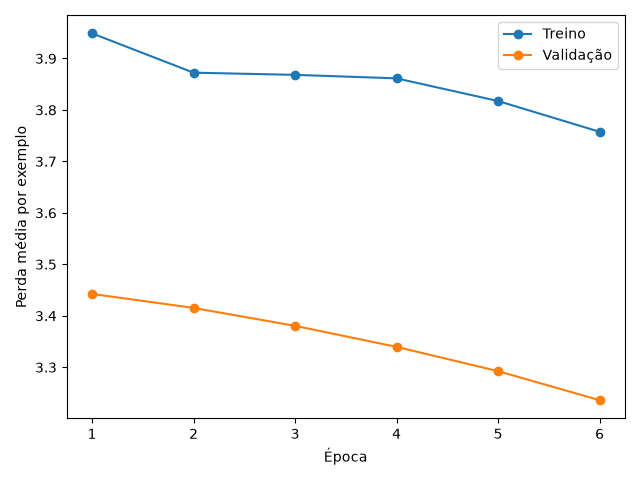

Época selecionada: 6
Perda no teste, base: 3.3887380599975585
Perda no teste, adaptado: 3.1454211235046388


In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "docs/results/loss.png")))
print("Época selecionada:", result["selected_epoch"])
print("Perda no teste, base:", result["base_test_loss"])
print("Perda no teste, adaptado:", result["adapted_test_loss"])

## Resultado qualitativo

A redução de perda observada não resolveu a tarefa: ainda há cópia da pergunta, mistura de idiomas e repetição. A pequena amostra e a capacidade do modelo limitam o resultado. A análise completa compara as respostas no quinto notebook.

O adaptador é um artefato experimental. Seu salvamento comprova a realização do fine-tuning, não a adequação para uso assistencial. O terceiro notebook demonstra seu carregamento real.